# Exploratory Data Analysis

Load the processed scan data and understand its structure, distributions, and patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Data

In [2]:
# Load the processed parquet file
parquet_path = Path('../data/processed/scans.parquet')
df = pd.read_parquet(parquet_path)

print(f"Loaded {len(df)} scan records")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Loaded 65 scan records
Shape: (65, 9)

Columns: ['experimentId', 'userName', 'targetScanStyle', 'targetClusterSize', 'scanIndex', 'timestampMs', 'deltaMs', 'elapsedMs', 'barcode']


## Data Overview

In [3]:
# Basic info
print("Data Types:")
print(df.dtypes)
print("\nFirst few rows:")
df.head(10)

Data Types:
experimentId         string
userName             string
targetScanStyle      string
targetClusterSize     Int64
scanIndex             Int64
timestampMs           Int64
deltaMs               Int64
elapsedMs             Int64
barcode              string
dtype: object

First few rows:


,experimentId,userName,targetScanStyle,targetClusterSize,scanIndex,timestampMs,deltaMs,elapsedMs,barcode
0,9c966049-e8f1-4625-924e-b6aaaf28a127,fors,compliant,5,0,1770842787192,<NA>,0,72879351095
1,9c966049-e8f1-4625-924e-b6aaaf28a127,fors,compliant,5,1,1770842787725,533,533,72879351095
2,9c966049-e8f1-4625-924e-b6aaaf28a127,fors,compliant,5,2,1770842788125,400,933,72879351095
3,9c966049-e8f1-4625-924e-b6aaaf28a127,fors,compliant,5,3,1770842788475,350,1283,72879351095
4,9c966049-e8f1-4625-924e-b6aaaf28a127,fors,compliant,5,4,1770842788758,283,1566,72879351095
5,9c966049-e8f1-4625-924e-b6aaaf28a127,fors,compliant,5,5,1770842790208,1450,3016,72879351095
6,9c966049-e8f1-4625-924e-b6aaaf28a127,fors,compliant,5,6,1770842790508,300,3316,72879351095
7,9c966049-e8f1-4625-924e-b6aaaf28a127,fors,compliant,5,7,1770842790792,284,3600,72879351095
8,9c966049-e8f1-4625-924e-b6aaaf28a127,fors,compliant,5,8,1770842791124,332,3932,72879351095
9,9c966049-e8f1-4625-924e-b6aaaf28a127,fors,compliant,5,9,1770842791325,201,4133,72879351095


In [4]:
# Experiment summary
print(f"Number of experiments: {df['experimentId'].nunique()}")
print(f"Number of users: {df['userName'].nunique()}")
print(f"Scan styles: {df['targetScanStyle'].unique()}")
print(f"\nScans per experiment:")
print(df.groupby('experimentId').size().describe())

Number of experiments: 2
Number of users: 1
Scan styles: <ArrowStringArray>
['compliant', 'non_compliant']
Length: 2, dtype: string

Scans per experiment:
count     2.000000
mean     32.500000
std       3.535534
min      30.000000
25%      31.250000
50%      32.500000
75%      33.750000
max      35.000000
dtype: float64


## Timing Analysis

In [5]:
# Delta timing (time between consecutive scans)
print("Delta Ms (time between scans) - milliseconds:")
print(df['deltaMs'].describe())
print(f"\nNull values: {df['deltaMs'].isna().sum()} (expected for first scan in each experiment)")

Delta Ms (time between scans) - milliseconds:
count          63.0
mean     411.095238
std      362.808032
min           200.0
25%           233.0
50%           267.0
75%           358.0
max          1501.0
Name: deltaMs, dtype: Float64

Null values: 2 (expected for first scan in each experiment)


In [6]:
# Elapsed timing (cumulative time within experiment)
print("Elapsed Ms (cumulative time within experiment):")
print(df['elapsedMs'].describe())

Elapsed Ms (cumulative time within experiment):
count           65.0
mean     6502.476923
std      4398.042623
min              0.0
25%           2951.0
50%           6016.0
75%           9833.0
max          15316.0
Name: elapsedMs, dtype: Float64


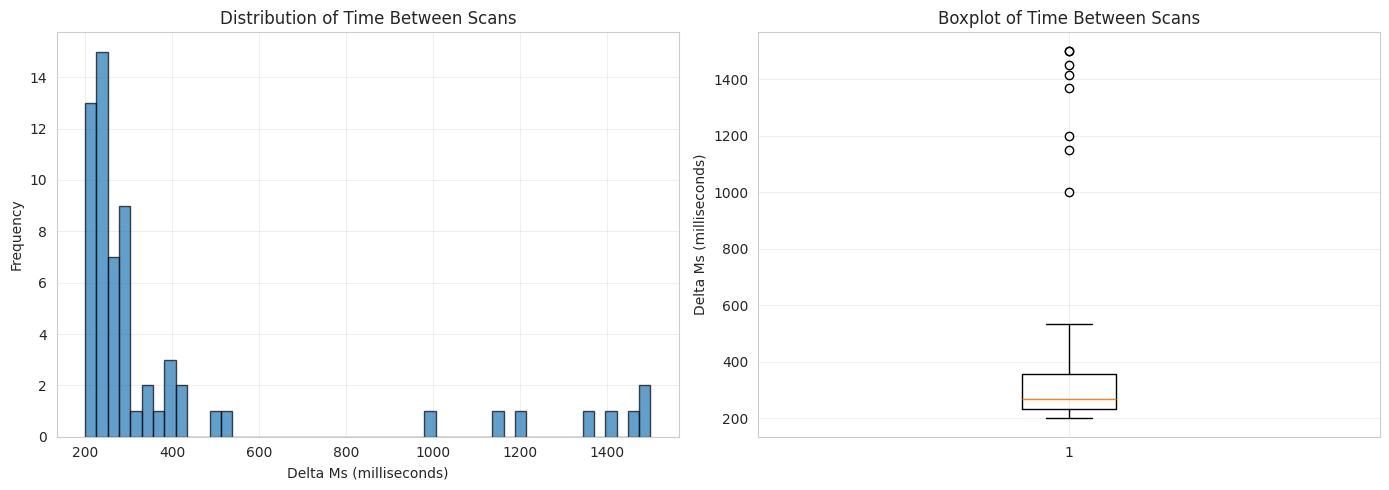

Delta Ms percentiles:
0.25      233.0
0.50      267.0
0.75      358.0
0.90     1120.0
0.95     1411.2
0.99    1500.38
Name: deltaMs, dtype: Float64


In [7]:
# Visualize delta timing distribution (excluding nulls)
delta_data = df['deltaMs'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(delta_data, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Delta Ms (milliseconds)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Time Between Scans')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(delta_data, vert=True)
axes[1].set_ylabel('Delta Ms (milliseconds)')
axes[1].set_title('Boxplot of Time Between Scans')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Delta Ms percentiles:")
print(delta_data.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

## Scan Style Analysis

In [8]:
# Compliance distribution (by experiment)
print(f"Scan style distribution by experiment:")
style_by_exp = df.groupby('experimentId')['targetScanStyle'].first()
print(style_by_exp.value_counts())
print(f"\nPercentage:")
print(style_by_exp.value_counts(normalize=True) * 100)

Scan style distribution by experiment:
targetScanStyle
compliant        1
non_compliant    1
Name: count, dtype: int64[pyarrow]

Percentage:
targetScanStyle
compliant        50.0
non_compliant    50.0
Name: proportion, dtype: double[pyarrow]


/tmp/ipykernel_1737/1165921011.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([compliant_deltas, noncompliant_deltas], labels=['Compliant', 'Non-Compliant'])


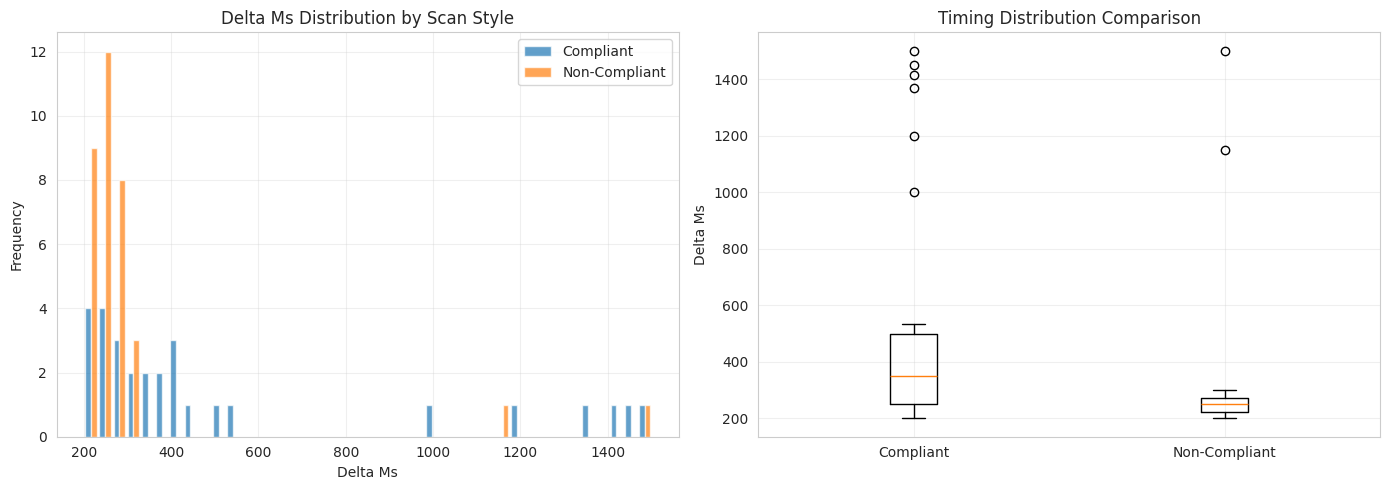

Compliant - Mean deltaMs: 528.1ms, Std: 428.8ms
Non-Compliant - Mean deltaMs: 311.3ms, Std: 262.6ms


In [9]:
# Compare timing between compliant and non-compliant
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Add style to dataframe for easier filtering
df_with_style = df.copy()
exp_styles = df.groupby('experimentId')['targetScanStyle'].first()
df_with_style['experimentStyle'] = df_with_style['experimentId'].map(exp_styles)

# Plot distributions by style
compliant_deltas = df_with_style[df_with_style['experimentStyle'] == 'compliant']['deltaMs'].dropna()
noncompliant_deltas = df_with_style[df_with_style['experimentStyle'] == 'non_compliant']['deltaMs'].dropna()

axes[0].hist([compliant_deltas, noncompliant_deltas], bins=40, label=['Compliant', 'Non-Compliant'], alpha=0.7)
axes[0].set_xlabel('Delta Ms')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Delta Ms Distribution by Scan Style')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot comparison
axes[1].boxplot([compliant_deltas, noncompliant_deltas], labels=['Compliant', 'Non-Compliant'])
axes[1].set_ylabel('Delta Ms')
axes[1].set_title('Timing Distribution Comparison')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Compliant - Mean deltaMs: {compliant_deltas.mean():.1f}ms, Std: {compliant_deltas.std():.1f}ms")
print(f"Non-Compliant - Mean deltaMs: {noncompliant_deltas.mean():.1f}ms, Std: {noncompliant_deltas.std():.1f}ms")

## Target Cluster Size Analysis

In [ ]:
# Cluster size distribution
print(f"Target cluster size distribution:")
cluster_sizes = df.groupby('experimentId')['targetClusterSize'].first()
print(cluster_sizes.value_counts().sort_index())

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
cluster_sizes.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Target Cluster Size')
ax.set_ylabel('Number of Experiments')
ax.set_title('Distribution of Target Cluster Sizes')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Sample Experiment Timeline

In [ ]:
# Pick a sample compliant experiment and visualize its scan timeline
compliant_exps = df[df['targetScanStyle'] == 'compliant']['experimentId'].unique()
sample_exp = compliant_exps[0]
sample_data = df[df['experimentId'] == sample_exp].sort_values('scanIndex')

print(f"Sample experiment: {sample_exp}")
print(f"Number of scans: {len(sample_data)}")
print(f"User: {sample_data['userName'].iloc[0]}, Style: {sample_data['targetScanStyle'].iloc[0]}")
print(f"Target cluster size: {sample_data['targetClusterSize'].iloc[0]}")
print(f"\nFirst 20 scans:")
print(sample_data[['scanIndex', 'deltaMs', 'elapsedMs']].head(20).to_string())

## Users and Barcode Analysis

# Timing statistics by user
print(f"Average deltaMs by user:")
for user in df['userName'].unique():
    user_deltas = df[df['userName'] == user]['deltaMs'].dropna()
    print(f"  {user}: {user_deltas.mean():.1f}ms (std: {user_deltas.std():.1f}ms)")

print("=== EXPLORATORY ANALYSIS SUMMARY ===")
print(f"\nDataset Size:")
print(f"  Total scans: {len(df)}")
print(f"  Experiments: {df['experimentId'].nunique()}")
print(f"  Users: {df['userName'].nunique()}")
print(f"  Unique barcodes: {df['barcode'].nunique()}")

print(f"\nExperiment Distribution:")
print(f"  Compliant: {(df.groupby('experimentId')['targetScanStyle'].first() == 'compliant').sum()}")
print(f"  Non-compliant: {(df.groupby('experimentId')['targetScanStyle'].first() == 'non_compliant').sum()}")

print(f"\nTiming Characteristics:")
print(f"  Mean deltaMs: {delta_data.mean():.1f}ms")
print(f"  Median deltaMs: {delta_data.median():.1f}ms")
print(f"  Std deltaMs: {delta_data.std():.1f}ms")
print(f"  Max deltaMs: {delta_data.max():.1f}ms")

print(f"\nTarget Cluster Sizes:")
print(f"  Range: {cluster_sizes.min()} to {cluster_sizes.max()}")
print(f"  Most common: {cluster_sizes.mode()[0] if len(cluster_sizes.mode()) > 0 else 'N/A'}")

print(f"\nNext Steps:")
print(f"  1. Detect clusters using timing patterns (see notebook 03)")
print(f"  2. Compare detected vs target cluster sizes")
print(f"  3. Build compliance classification model")
print(f"  4. Detect anomalous patterns")